In [7]:
import trino
import pandas as pd
import seaborn as sns
from minio import Minio

In [8]:
client = Minio(
    "localhost:9000",
    access_key="admin",
    secret_key="admin123",
    secure=False,
)

bucket_name = "demo-iceberg-warehouse"

if not client.bucket_exists(bucket_name):
    client.make_bucket(bucket_name)

# Уровень 1 — Подключения

In [9]:
conn = trino.dbapi.connect(
    host="localhost",
    port=8080,
    user="student",
    catalog="iceberg",
    schema="demo",
)

In [10]:
cur = conn.cursor()

In [11]:
def q(sql):
    cur.execute(sql)
    rows = cur.fetchall()
    return pd.DataFrame(rows, columns=[c[0] for c in cur.description]) if cur.description else None

In [12]:
q("SELECT 1 AS ok")

,ok
0,1


In [13]:
q("SHOW CATALOGS")

,Catalog
0,iceberg
1,minio
2,mysql
3,postgres
4,system


In [14]:
q("SHOW SCHEMAS FROM postgres")

,Schema
0,information_schema
1,pg_catalog
2,public


In [15]:
q("SHOW TABLES FROM postgres.public")

,Table
0,iceberg_namespace_properties
1,iceberg_tables
2,trn_customers
3,trn_events
4,trn_orders


In [16]:
q("SHOW SCHEMAS FROM mysql")

,Schema
0,demo_db
1,information_schema
2,performance_schema


In [17]:
q("SHOW TABLES FROM mysql.demo_db")

,Table
0,trn_payments


In [18]:
q("SHOW SCHEMAS FROM iceberg")

,Schema
0,information_schema
1,system


# Уровень 2 — Агрегация данных

In [19]:
df_orders_count_by_date = q("select date(order_ts) as report_date, count(distinct order_id) as orders_count from postgres.public.trn_orders group by date(order_ts) order by report_date desc")

In [20]:
df_average_amount_by_date = q("select date(order_ts) as report_date, avg(total_amount) as average_amount from postgres.public.trn_orders group by date(order_ts) order by report_date desc")

# Уровень 3 — Визуализация и Iceberg

In [21]:
q("CREATE SCHEMA IF NOT EXISTS iceberg.analytics WITH (location = 's3://demo-iceberg-warehouse/analytics/')")

<Axes: xlabel='report_date', ylabel='orders_count'>

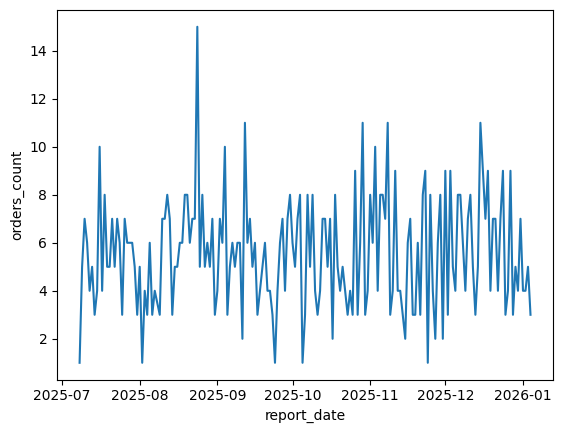

In [22]:
sns.lineplot(df_orders_count_by_date, x="report_date", y="orders_count")

In [23]:
q("CREATE TABLE IF NOT EXISTS iceberg.analytics.orders_count_by_date (report_date DATE, orders_count BIGINT) WITH (format = 'PARQUET')")

In [24]:
q("insert INTO iceberg.analytics.orders_count_by_date SELECT date(order_ts) as report_date, count(distinct order_id) as orders_count from postgres.public.trn_orders group by date(order_ts)")

,rows
0,180


In [25]:
df = q("""
SELECT *
FROM iceberg.analytics.orders_count_by_date
ORDER BY report_date DESC
LIMIT 20
""")

In [26]:
df

,report_date,orders_count
0,2026-01-04,3
1,2026-01-03,5
2,2026-01-02,4
3,2026-01-01,4
4,2025-12-31,7
5,2025-12-30,4
6,2025-12-29,5
7,2025-12-28,3
8,2025-12-27,9
9,2025-12-26,4


In [27]:
df_orders_count_by_date.head(20)

,report_date,orders_count
0,2026-01-04,3
1,2026-01-03,5
2,2026-01-02,4
3,2026-01-01,4
4,2025-12-31,7
5,2025-12-30,4
6,2025-12-29,5
7,2025-12-28,3
8,2025-12-27,9
9,2025-12-26,4


<Axes: xlabel='report_date', ylabel='average_amount'>

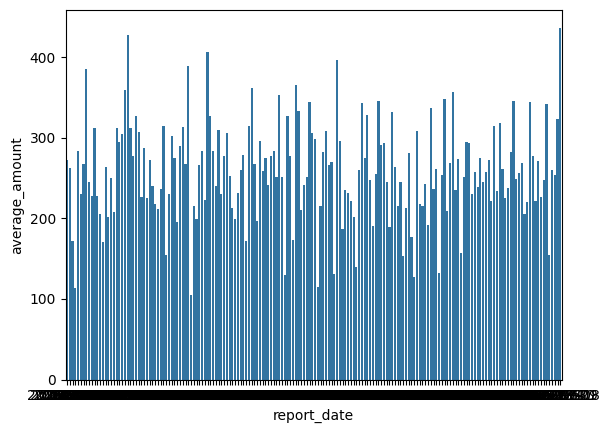

In [28]:
sns.barplot(df_average_amount_by_date, x="report_date", y="average_amount")

In [29]:
q("CREATE TABLE IF NOT EXISTS iceberg.analytics.amount_avg_by_date (report_date DATE, average_amount DOUBLE) WITH (format = 'PARQUET')")

In [30]:
q("insert into iceberg.analytics.amount_avg_by_date SELECT date(order_ts) as report_date, avg(total_amount) as average_amount from postgres.public.trn_orders group by date(order_ts)")

,rows
0,180


In [31]:
df = q("""
SELECT *
FROM iceberg.analytics.amount_avg_by_date
ORDER BY report_date DESC
LIMIT 20
""")

In [32]:
df

,report_date,average_amount
0,2026-01-04,271.90
1,2026-01-03,262.87
2,2026-01-02,171.27
3,2026-01-01,113.20
4,2025-12-31,283.23
5,2025-12-30,229.92
6,2025-12-29,267.19
7,2025-12-28,384.88
8,2025-12-27,245.56
9,2025-12-26,227.70


In [33]:
df_average_amount_by_date.head(20)

,report_date,average_amount
0,2026-01-04,271.90
1,2026-01-03,262.87
2,2026-01-02,171.27
3,2026-01-01,113.20
4,2025-12-31,283.23
5,2025-12-30,229.92
6,2025-12-29,267.19
7,2025-12-28,384.88
8,2025-12-27,245.56
9,2025-12-26,227.70
